In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('../data/health_insurance_clean.csv')

## **Distribution of our target variable**

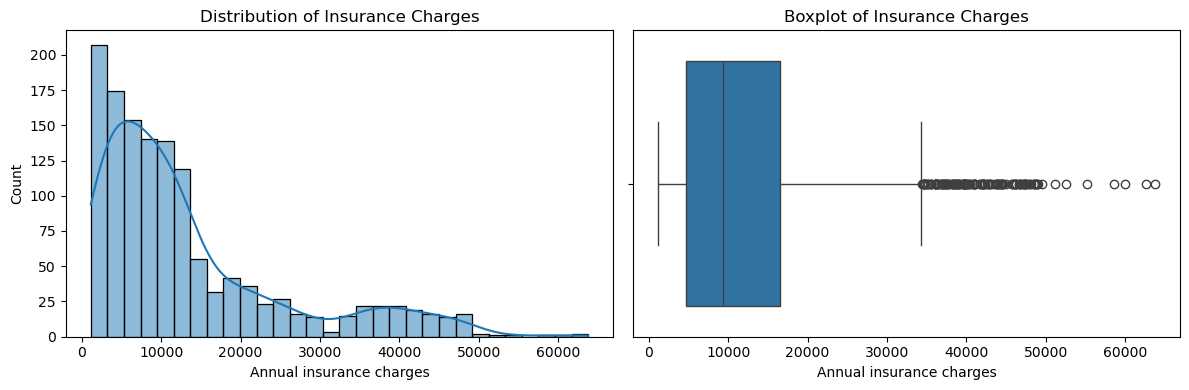

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=data, x="charges", kde=True, ax=axes[0])
axes[0].set_title("Distribution of Insurance Charges")
axes[0].set_xlabel("Annual insurance charges")

sns.boxplot(data=data, x="charges", ax=axes[1])
axes[1].set_title("Boxplot of Insurance Charges")
axes[1].set_xlabel("Annual insurance charges")

plt.tight_layout()
plt.show()

We also look at the skewness:

In [5]:
print("Charges skewness:", data["charges"].skew())

Charges skewness: 1.5225407729011506


Our target variable is strongly right skewed

## **Look at categorical feature distribtuion**

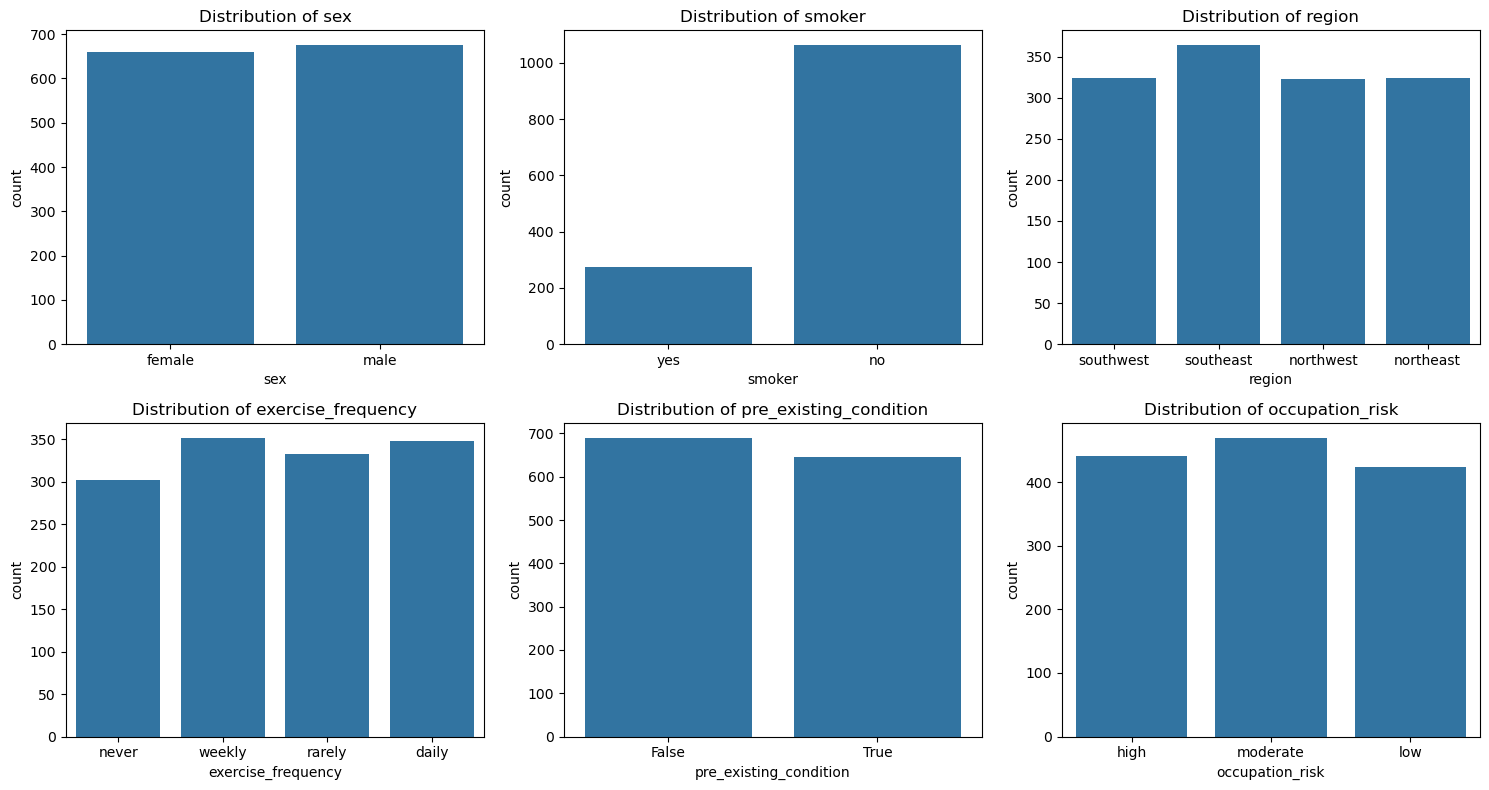

In [13]:
categorical_columns = ["sex", "smoker", "region", "exercise_frequency", "pre_existing_condition", "occupation_risk"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    sns.countplot(data=data, x=column, ax=ax)
    ax.set_title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

All categories besides smoker, exercise frequency are relatively balanced. That is good because among these no category is strongly underrepresented.

Smokers is really unbalanced: the smoker subgroup contains less observations.

Concerning exercise_frequency only the exercise frequency never is a bit under represented.

## **Look at numerical feature distribtuion**

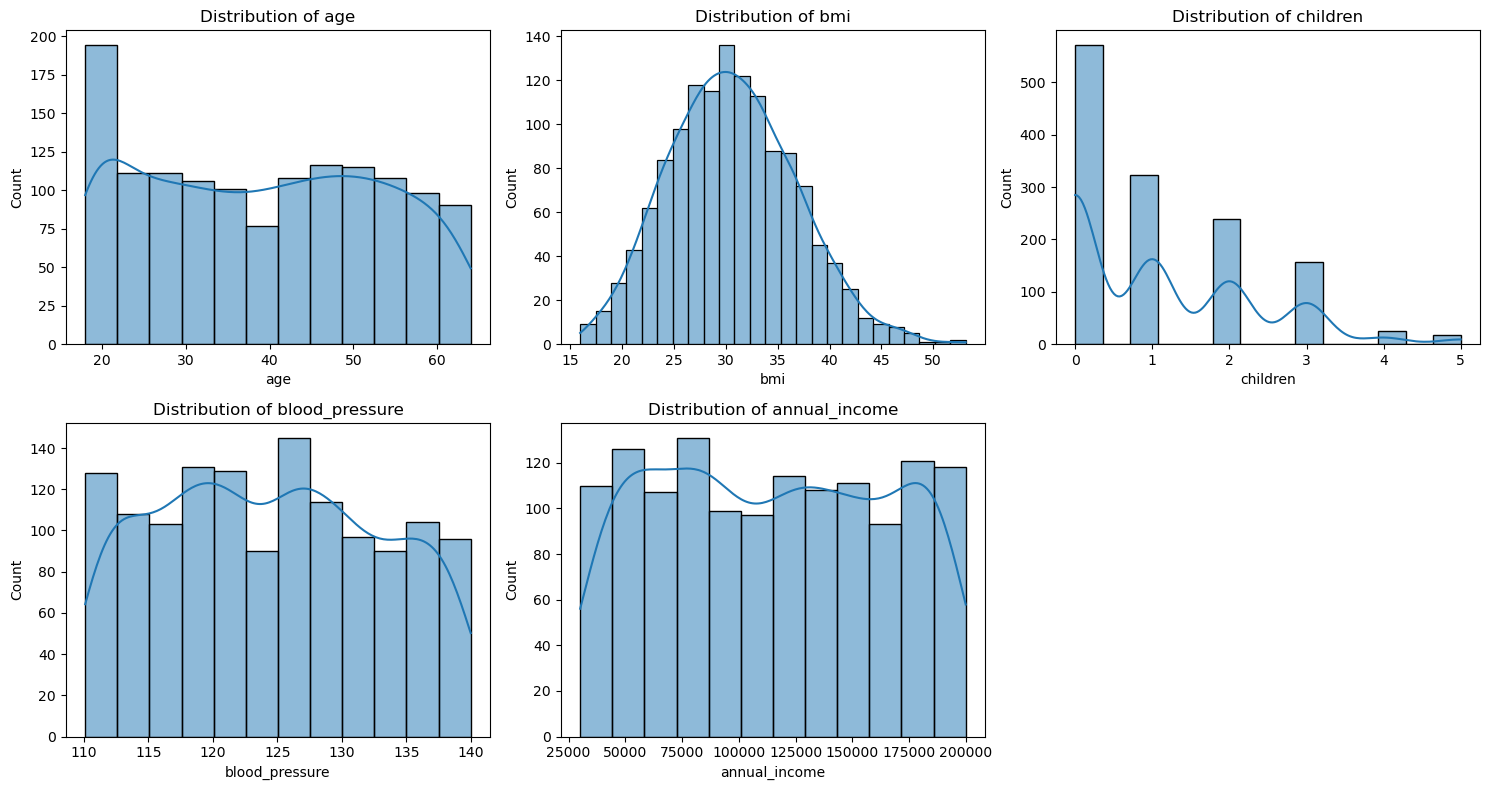

In [14]:
numerical_features = ["age", "bmi", "children", "blood_pressure", "annual_income"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, column in zip(axes, numerical_features):
    sns.histplot(data=data, x=column, kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

Age appears broadly spread around 18 and 64. The distribution looks approximately uniformly distributed besides the spike at age 20.

Bmi is approximately bell shaped centered around 30. 

The distribution for children looks reasonable.

Blood pressure and annual income look almost also uniformly distributed

## **Charges by categorical feature**

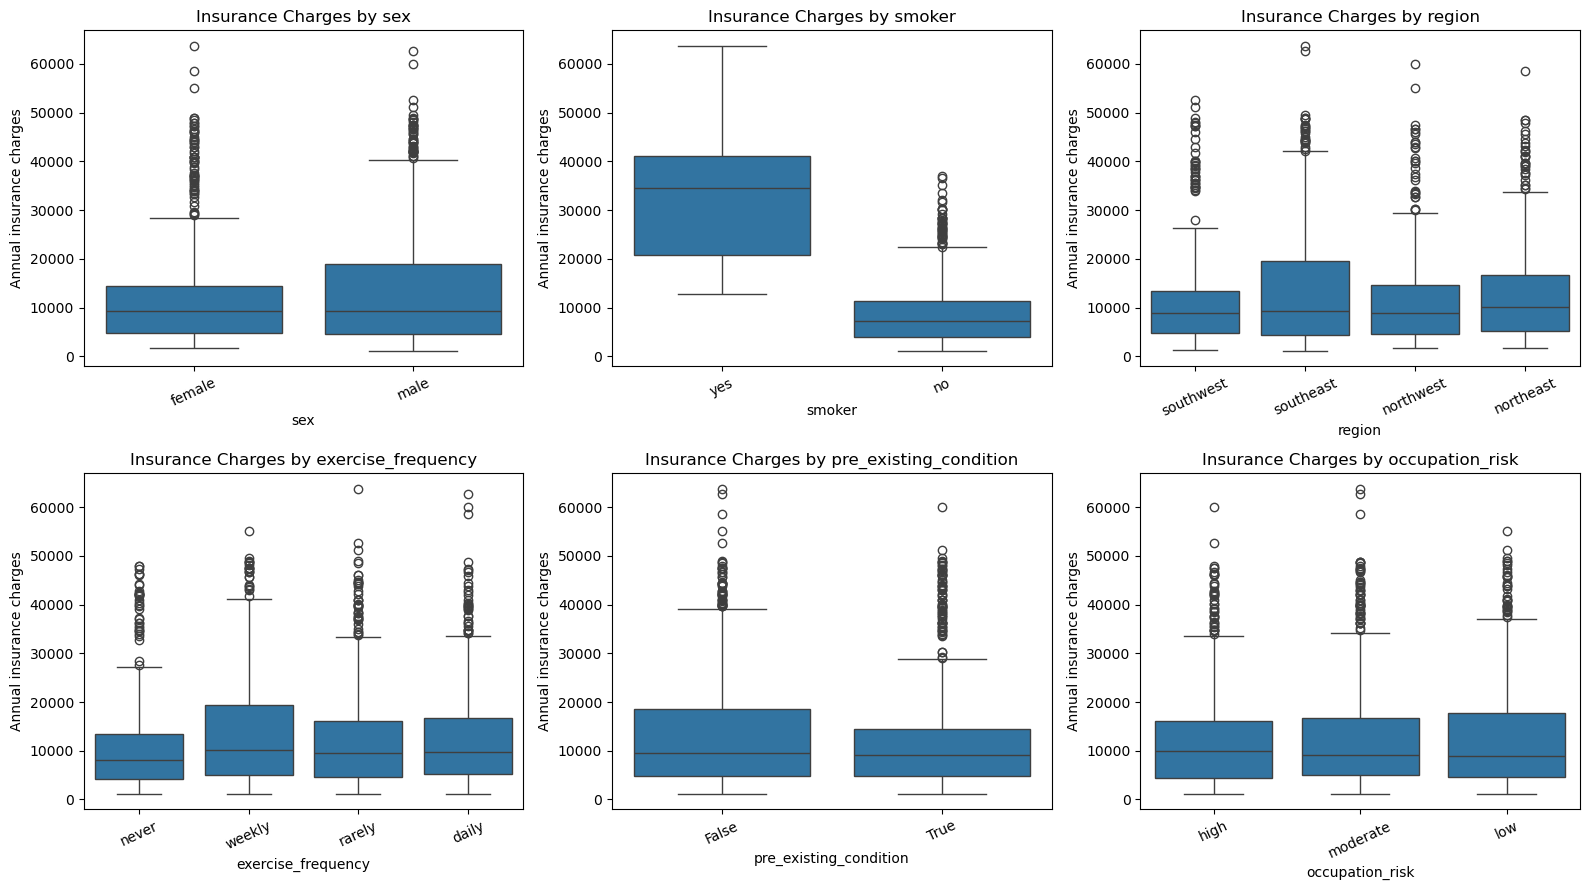

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    sns.boxplot(
        data=data,
        x=column,
        y="charges",
        ax=ax
    )

    ax.set_title(f"Insurance Charges by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Annual insurance charges")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

Smokers have higher insurance charges, with a median of around 35,000 compared with less than 10,000 for non-smokers. This suggests that smoking status is a strong predictor of insurance charges. Regions and exercise-frequency groups show smaller differences in their median charges, but their distributions overlap considerably. Sex, pre-existing conditions, and occupation risk show only minor differences between groups.

## **Numerical predictors against charges**

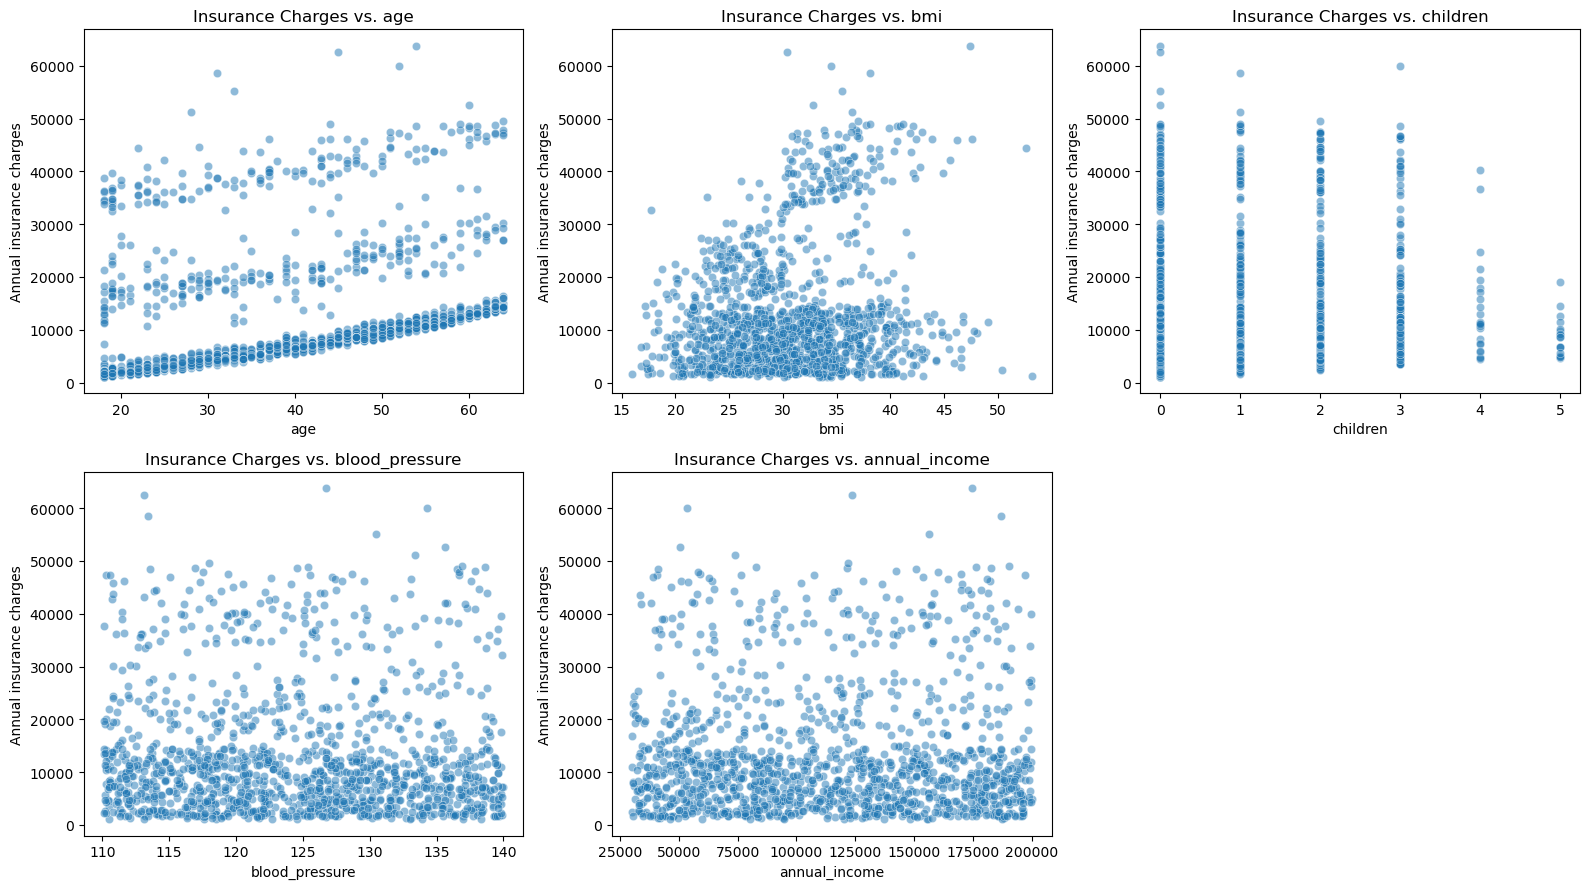

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, column in zip(axes, numerical_features):
    sns.scatterplot(
        data=data,
        x=column,
        y="charges",
        alpha=0.5,
        ax=ax
    )

    ax.set_title(f"Insurance Charges vs. {column}")
    ax.set_ylabel("Annual insurance charges")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

Age shows a clear positive relationship with insurance charges. BMI also appears to be positively associated with charges, although the relationship is weaker and seems to depend on different subgroups. For the remaining numerical variables, no strong relationship with insurance charges is visible.


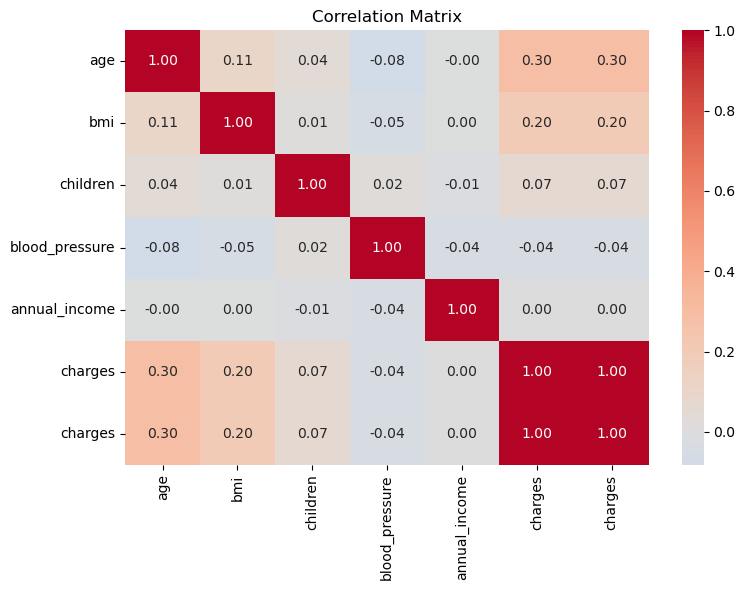

In [24]:
correlation_columns = numerical_features + ["charges"]

correlation_matrix = data[correlation_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Age has the strongest positive correlation with insurance charges at 0.30, followed by BMI at 0.20. The number of children shows only a very weak positive correlation. Blood pressure and annual income show almost no linear relationship with charges.

## **Summary**

Insurance charges are right skewed, with a smaller number of observations having very high charges. Smoking status shows the clearest relationship with charges, as smokers have higher charges than non smokers. Age has the strongest positive numerical relationship with charges, followed by BMI. The remaining variables show only weak or no clear relationships with the target. These findings suggest that smoking status, age, and BMI are likely to be especially useful predictors in the subsequent regression models.